# Loading KBase Genome Objects into ModelSEEDpy

This notebook demonstrates how to load genome object JSON files from the `genome_objects` directory and use them with ModelSEEDpy for metabolic modeling.

## Prerequisites

Make sure you have ModelSEEDpy installed:
```bash
pip install modelseedpy
```

## Setup

Import the genome loading utilities:

In [1]:
from load_genomes_to_modelseedpy import (
    list_available_genomes,
    load_genome,
    load_all_genomes,
    get_msgenome,
    build_model,
    export_genome_summary,
    GenomeLoader
)

import pandas as pd
import json

modelseedpy 0.3.3


## 1. List Available Genomes

First, let's see what genomes are available in the `genome_objects` directory:

In [ ]:
# List all available genomes
genomes = list_available_genomes()

print(f"Found {len(genomes)} genomes")
print("\nFirst 20 genomes:")
for genome_id in genomes[:20]:
    print(f"  - {genome_id}")

## 2. Load a Single Genome

Load and inspect a single genome object:

In [ ]:
# Load a single genome
genome_id = 'Acetobacterium.1'
genome = load_genome(genome_id)

# Display genome information
print(f"Genome ID: {genome['id']}")
print(f"Scientific name: {genome['scientific_name']}")
print(f"Domain: {genome['domain']}")
print(f"Taxonomy: {genome['taxonomy']}")
print(f"\nStatistics:")
print(f"  Features: {len(genome['features'])}")
print(f"  CDSs: {len(genome['cdss'])}")
print(f"  DNA size: {genome['dna_size']:,} bp")
print(f"  GC content: {genome['gc_content']:.2%}")
print(f"  Contigs: {genome['num_contigs']}")

### Inspect genome features

In [ ]:
# Look at the first few features
print("First 5 features:")
for feature in genome['features'][:5]:
    print(f"\nFeature ID: {feature['id']}")
    print(f"  Type: {feature['type']}")
    print(f"  Functions: {feature.get('functions', [])}")
    print(f"  DNA length: {feature['dna_sequence_length']} bp")
    if 'protein_translation' in feature:
        print(f"  Protein length: {feature['protein_translation_length']} aa")

## 3. Load All Genomes

Load all genome objects at once:

In [ ]:
# Load all genomes (this may take a minute)
all_genomes = load_all_genomes(verbose=True)

### Summary statistics

In [ ]:
# Calculate summary statistics
total_features = sum(len(g['features']) for g in all_genomes.values())
total_dna = sum(g['dna_size'] for g in all_genomes.values())
avg_gc = sum(g['gc_content'] for g in all_genomes.values()) / len(all_genomes)

print(f"Summary across {len(all_genomes)} genomes:")
print(f"  Total features: {total_features:,}")
print(f"  Total DNA: {total_dna:,} bp ({total_dna/1e9:.2f} Gbp)")
print(f"  Average GC content: {avg_gc:.2%}")

## 4. Create a Genome Summary Table

Export and visualize a summary of all genomes:

In [2]:
# Export to TSV
export_genome_summary('genome_summary.tsv')

# Load and display as pandas DataFrame
df = pd.read_csv('genome_summary.tsv', sep='\t')
print(f"\nGenome summary table ({len(df)} genomes):")
df

Exporting summary for 459 genomes to genome_summary.tsv
Loading genome: Acetoanaerobium.1
  Scientific name: Bacteria
  Taxonomy: Bacteria...
  Features: 2595
  DNA size: 0 bp
  GC content: 39.61%
Loading genome: Acetobacterium.1
  Scientific name: Bacteria
  Taxonomy: Bacteria...
  Features: 3320
  DNA size: 0 bp
  GC content: 42.58%
Loading genome: Acholeplasma.2
  Scientific name: Bacteria
  Taxonomy: Bacteria...
  Features: 655
  DNA size: 0 bp
  GC content: 39.13%
Loading genome: Achromobacter.1
  Scientific name: Bacteria
  Taxonomy: Bacteria...
  Features: 18009
  DNA size: 0 bp
  GC content: 65.53%
Loading genome: Achromobacter.2
  Scientific name: Bacteria
  Taxonomy: Bacteria...
  Features: 5728
  DNA size: 0 bp
  GC content: 65.92%
Loading genome: Acinetobacter.2
  Scientific name: Bacteria
  Taxonomy: Bacteria...
  Features: 9845
  DNA size: 0 bp
  GC content: 39.54%
Loading genome: Acinetobacter.3
  Scientific name: Bacteria
  Taxonomy: Bacteria...
  Features: 4538
  DNA s

,genome_id,scientific_name,domain,taxonomy,num_features,num_cdss,dna_size,gc_content,num_contigs
0,Acetoanaerobium.1,Bacteria,Bacteria,Bacteria,2595,2595,0,0.3961,2595
1,Acetobacterium.1,Bacteria,Bacteria,Bacteria,3320,3320,0,0.4258,3320
2,Acholeplasma.2,Bacteria,Bacteria,Bacteria,655,655,0,0.3913,655
3,Achromobacter.1,Bacteria,Bacteria,Bacteria,18009,18009,0,0.6553,18009
4,Achromobacter.2,Bacteria,Bacteria,Bacteria,5728,5728,0,0.6592,5728
...,...,...,...,...,...,...,...,...,...
454,midas_g_97954.2,Bacteria,Bacteria,Bacteria,12951,12951,0,0.4462,12951
455,midas_g_97954.3,Bacteria,Bacteria,Bacteria,12840,12840,0,0.4131,12840
456,midas_g_98017.1,Bacteria,Bacteria,Bacteria,4112,4112,0,0.4985,4112
457,midas_g_98017.2,Bacteria,Bacteria,Bacteria,2515,2515,0,0.5686,2515


### Visualize genome statistics

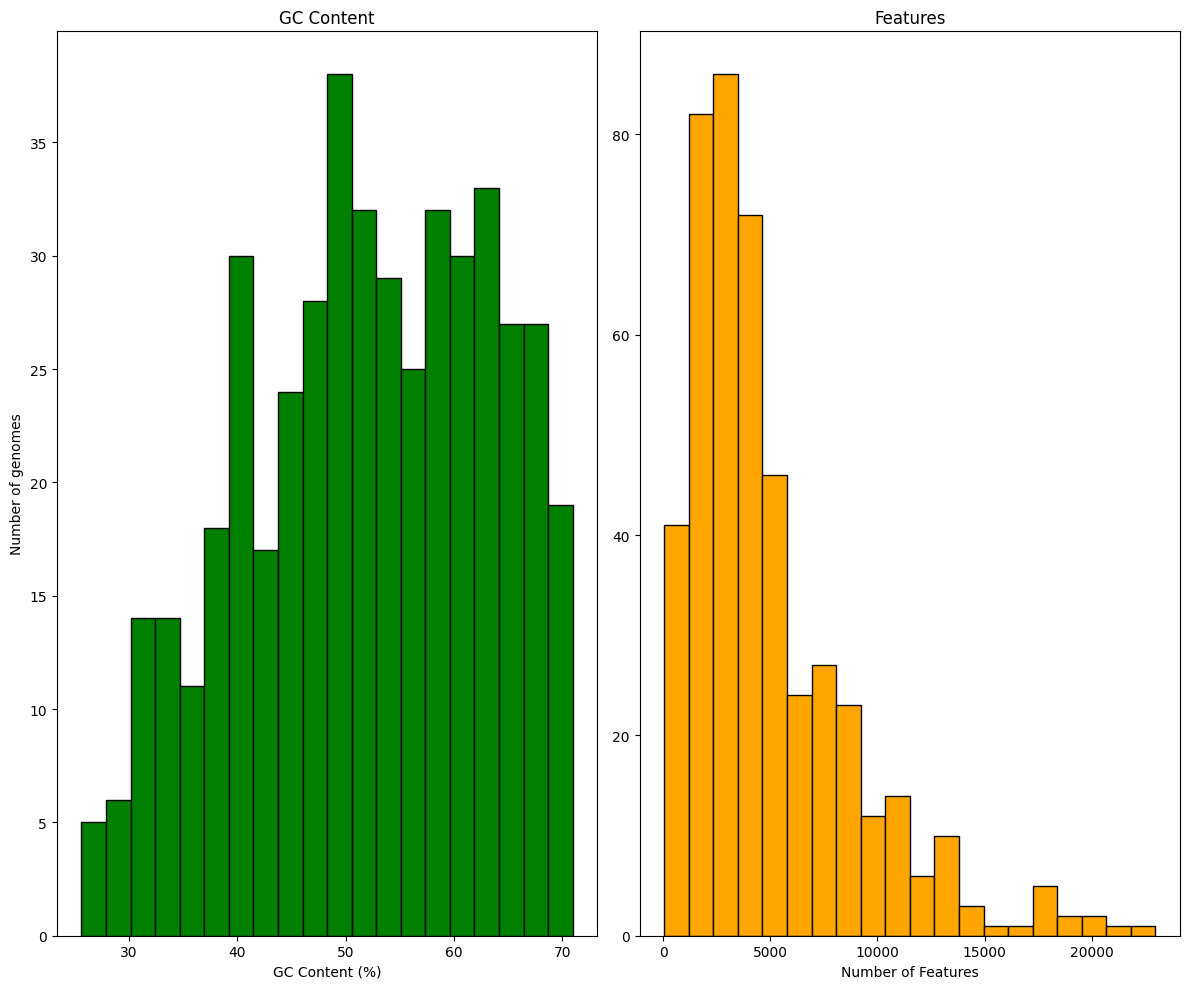

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 10))

# DNA size distribution
# axes[0, 0].hist(df['dna_size'] / 1e6, bins=20, edgecolor='black')
# axes[0, 0].set_xlabel('Genome Size (Mbp)')
# axes[0, 0].set_ylabel('Count')
# axes[0, 0].set_title('Distribution of Genome Sizes')

# GC content distribution
axes[0].hist(df['gc_content'] * 100, bins=20, edgecolor='black', color='green')
axes[0].set_xlabel('GC Content (%)')
axes[0].set_ylabel('Number of genomes')
axes[0].set_title('GC Content')

# Number of features
axes[1].hist(df['num_features'], bins=20, edgecolor='black', color='orange')
axes[1].set_xlabel('Number of Features')
# axes[1].set_ylabel('Number of genomes')
axes[1].set_title('Features')

# Domain distribution
# domain_counts = df['domain'].value_counts()
# axes[1, 1].pie(domain_counts.values, labels=domain_counts.index, autopct='%1.1f%%')
# axes[1, 1].set_title('Distribution by Domain')

plt.tight_layout()
plt.savefig("genome_objects/")

## 5. Create MSGenome Objects

Convert KBase genomes to ModelSEEDpy MSGenome objects:

In [ ]:
# Create MSGenome object
genome_id = 'Acetobacterium.1'
msgenome = get_msgenome(genome_id)

print(f"MSGenome created for {genome_id}")
print(f"  ID: {msgenome.id}")
print(f"  Features: {len(msgenome.features)}")

## 6. Build Metabolic Models

Build genome-scale metabolic models using ModelSEEDpy:

In [ ]:
# Build a metabolic model
genome_id = 'Acetobacterium.1'
model = build_model(genome_id, template='GramPositive')

print(f"\nModel statistics:")
print(f"  Reactions: {len(model.reactions)}")
print(f"  Metabolites: {len(model.metabolites)}")
print(f"  Genes: {len(model.genes)}")

### Test the model with FBA

In [ ]:
# Run flux balance analysis
solution = model.optimize()

print(f"Optimization status: {solution.status}")
if solution.status == 'optimal':
    print(f"Objective value: {solution.objective_value:.4f}")
    print(f"\nTop 10 fluxes:")
    fluxes = solution.fluxes.abs().sort_values(ascending=False)
    for rxn_id, flux in fluxes.head(10).items():
        rxn = model.reactions.get_by_id(rxn_id)
        print(f"  {rxn_id}: {flux:.3f} - {rxn.name}")
else:
    print("Model may need gap-filling to achieve growth")

### Save the model

In [ ]:
# Save model to SBML file
from cobra.io import write_sbml_model

output_file = f"{genome_id}_model.xml"
write_sbml_model(model, output_file)
print(f"Model saved to {output_file}")

## 7. Batch Process Multiple Genomes

Build models for multiple genomes:

In [ ]:
# Select a few genomes to process
genome_ids_to_process = list_available_genomes()[:5]

print(f"Building models for {len(genome_ids_to_process)} genomes...\n")

models = {}
for genome_id in genome_ids_to_process:
    try:
        print(f"Processing {genome_id}...")
        model = build_model(genome_id)
        models[genome_id] = model
        
        # Test optimization
        solution = model.optimize()
        print(f"  Status: {solution.status}")
        if solution.status == 'optimal':
            print(f"  Growth: {solution.objective_value:.4f}")
        print()
        
    except Exception as e:
        print(f"  Error: {e}\n")
        continue

print(f"Successfully built {len(models)} models")

## 8. Advanced: Genome Comparison

Compare features across multiple genomes:

In [ ]:
# Load a few genomes for comparison
comparison_genomes = {gid: load_genome(gid) for gid in list_available_genomes()[:5]}

# Collect all unique functions
all_functions = set()
for genome in comparison_genomes.values():
    for feature in genome['features']:
        all_functions.update(feature.get('functions', []))

print(f"Total unique functions across {len(comparison_genomes)} genomes: {len(all_functions)}")

# Create presence/absence matrix
function_matrix = {}
for func in list(all_functions)[:20]:  # Just first 20 for display
    function_matrix[func] = {}
    for genome_id, genome in comparison_genomes.items():
        # Check if this function exists in the genome
        has_function = any(
            func in feature.get('functions', [])
            for feature in genome['features']
        )
        function_matrix[func][genome_id] = 1 if has_function else 0

# Convert to DataFrame
comparison_df = pd.DataFrame(function_matrix).T
print("\nFunction presence/absence matrix (1 = present, 0 = absent):")
comparison_df

## Summary

This notebook demonstrated how to:
1. List available genome objects
2. Load individual or all genomes
3. Inspect genome structure and features
4. Create summary tables and visualizations
5. Convert to ModelSEEDpy MSGenome objects
6. Build and analyze metabolic models
7. Batch process multiple genomes
8. Compare genomes

For more information, see:
- `load_genomes_to_modelseedpy.py` - Main loading utilities
- `example_load_genomes.py` - Additional examples
- ModelSEEDpy documentation: https://github.com/ModelSEED/ModelSEEDpy